## Cost of living data analysis
  This project will focus on the analysis of various categories contributing to the general cost of living, with a focus on staple food products, inflation, and wages. We are aiming to answer the following questions throughout the course of our analysis:


  1. How has the price of unhealthy foods increased over the years in comparison to the increase of price of healthy foods over the years?

  2. How has the cost of paying for groceries for a family of 4 changed over the years (3.13 as the national average of people in household)?
  
  3. How has the price of groceries increased in comparison to inflation over the years?

  4. How has the price of groceries increased in comparison to wages over the years?

  5. How do children in a household affect the cost of living grocery-wise over the years?



## How has the price of unhealthy foods increased over the years in comparison to the increase of price of healthy foods over the years?

Saving DataDownload.xls to DataDownload.xls
=== Milk vs. Soda Price Analysis (2010) ===
Average milk price:           $0.973
Average soda price:           $0.992
Average milk-to-soda ratio:   0.910
Counties where soda cheaper:  2050 / 3109 (65.9%)
Counties where milk cheaper:  1059 / 3109 (34.1%)


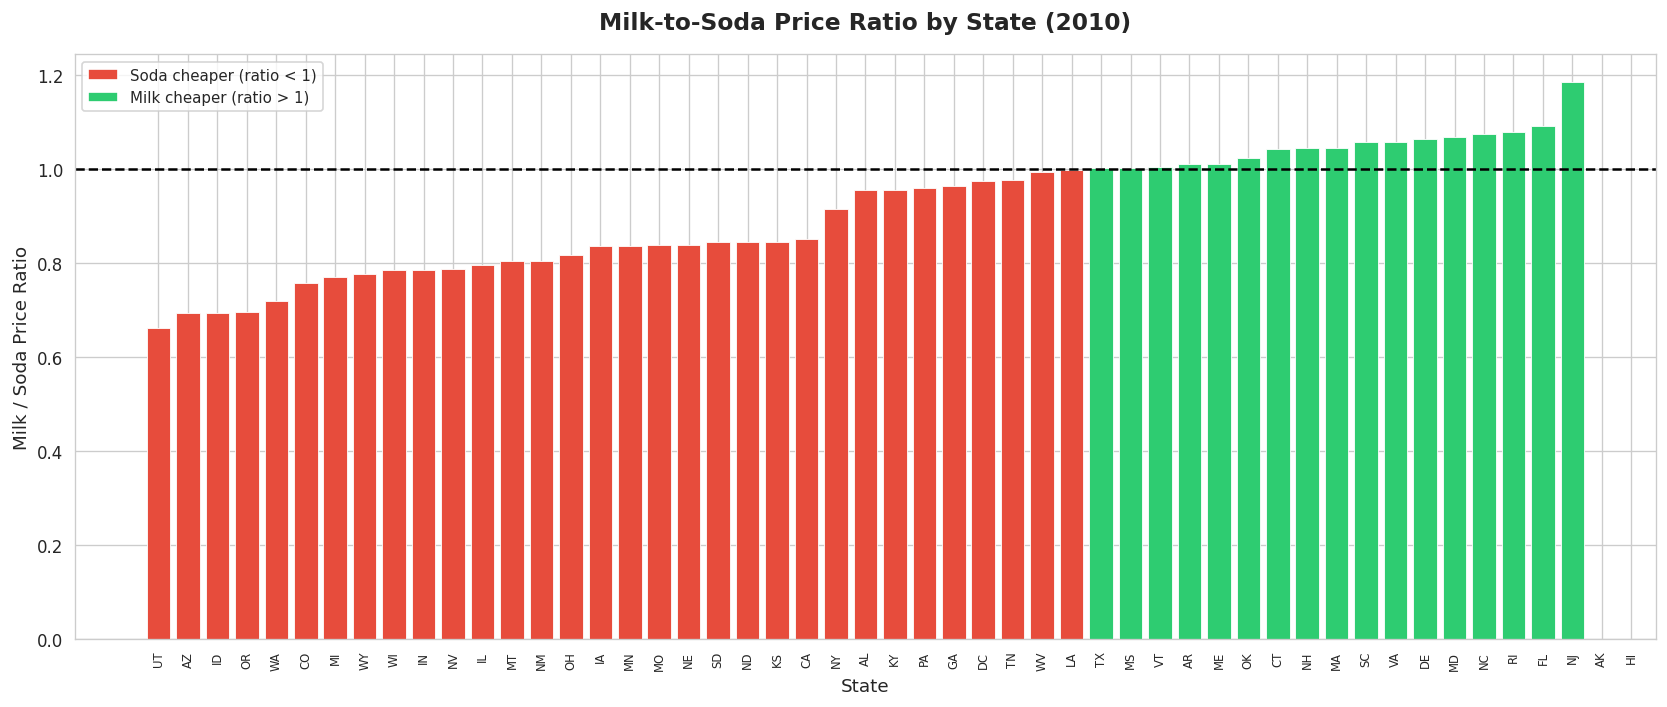

In [ ]:
!pip install xlrd -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

from google.colab import files
uploaded = files.upload()

XLS_PATH = 'DataDownload.xls'
os.makedirs('charts', exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load data
prices = pd.read_excel(XLS_PATH, engine='xlrd', sheet_name='PRICES_TAXES')

# Stats
cheaper_soda = (prices['MILK_SODA_PRICE10'] < 1).sum()
cheaper_milk = (prices['MILK_SODA_PRICE10'] > 1).sum()
total        = prices['MILK_SODA_PRICE10'].notna().sum()

print('=== Milk vs. Soda Price Analysis (2010) ===')
print(f'Average milk price:           ${prices["MILK_PRICE10"].mean():.3f}')
print(f'Average soda price:           ${prices["SODA_PRICE10"].mean():.3f}')
print(f'Average milk-to-soda ratio:   {prices["MILK_SODA_PRICE10"].mean():.3f}')
print(f'Counties where soda cheaper:  {cheaper_soda} / {total} ({cheaper_soda/total*100:.1f}%)')
print(f'Counties where milk cheaper:  {cheaper_milk} / {total} ({cheaper_milk/total*100:.1f}%)')

# Chart
state_ratio = prices.groupby('State')['MILK_SODA_PRICE10'].mean().sort_values()
colors = ['#e74c3c' if v < 1 else '#2ecc71' for v in state_ratio.values]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(state_ratio.index, state_ratio.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(1, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Milk-to-Soda Price Ratio by State (2010)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Milk / Soda Price Ratio', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(handles=[
    mpatches.Patch(facecolor='#e74c3c', label='Soda cheaper (ratio < 1)'),
    mpatches.Patch(facecolor='#2ecc71', label='Milk cheaper (ratio > 1)')
], fontsize=9)
plt.tight_layout()
plt.savefig('charts/milk_soda_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## How has the cost of paying for groceries for a family of 4 changed over the years (3.13 as the national average of people in household)?
    
    

Saving cnpp-moderatecostplan-sept2007-present.xlsx to cnpp-moderatecostplan-sept2007-present.xlsx
Saving usda-moderatecostplan-pre-march2003.xlsx to usda-moderatecostplan-pre-march2003.xlsx
Saving usda-moderatecostplan-march2003-aug2007.xlsx to usda-moderatecostplan-march2003-aug2007.xlsx


Saving cnpp-moderatecostplan-sept2007-present.xlsx to cnpp-moderatecostplan-sept2007-present (1).xlsx
Saving usda-moderatecostplan-pre-march2003.xlsx to usda-moderatecostplan-pre-march2003 (1).xlsx
Saving usda-moderatecostplan-march2003-aug2007.xlsx to usda-moderatecostplan-march2003-aug2007 (1).xlsx


Saving cnpp-moderatecostplan-sept2007-present.xlsx to cnpp-moderatecostplan-sept2007-present (2).xlsx
Saving usda-moderatecostplan-pre-march2003.xlsx to usda-moderatecostplan-pre-march2003 (2).xlsx
Saving usda-moderatecostplan-march2003-aug2007.xlsx to usda-moderatecostplan-march2003-aug2007 (2).xlsx
(327, 9)
 From 1994 to 2021, the average moderate 4-family foodplan had a percent change of: 85.63402162928556
The average annual change in price is: 229.39191919191924
The average annual percent change is: 2.3357600130576066


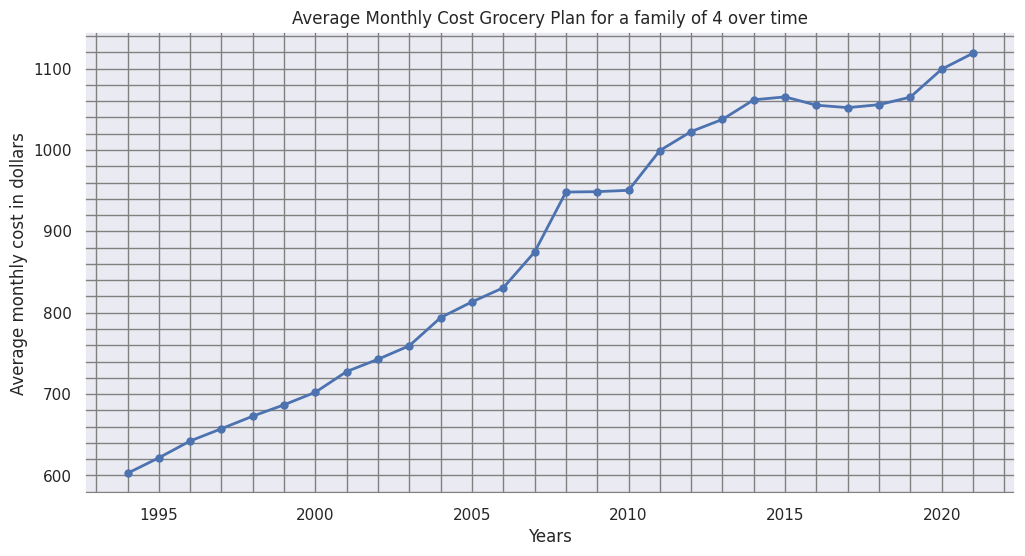

In [ ]:
uploaded2 = files.upload()

#First we read the 3 food plan sets using pandas
pre_2003_foodplan = pd.read_excel("usda-moderatecostplan-pre-march2003.xlsx", sheet_name='Moderate-Cost 94-03')
foodplan_03_07 = pd.read_excel("usda-moderatecostplan-march2003-aug2007.xlsx", sheet_name="Moderate-Cost 03-07")
foodplan_07_present = pd.read_excel("cnpp-moderatecostplan-sept2007-present.xlsx", sheet_name="Moderate-Cost 07-Pres")

#We then applied a few filters ensuring we were only grabbing monthly data pertaining to the U.S
norm1 = pre_2003_foodplan[(pre_2003_foodplan['geographic_area'] == "Mainland U.S.") & (pre_2003_foodplan['frequency'] == 'Monthly')].copy()
norm2 = foodplan_03_07[(foodplan_03_07['geographic_area'] == "Mainland U.S.") & (foodplan_03_07['frequency'] == 'Monthly')].copy()
norm3 = foodplan_07_present[(foodplan_07_present['location'] == "Mainland U.S.") & (foodplan_07_present['frequency'] == "Monthly")].copy()

#We then normalized some column names and converted the year and cost columns to numbers for analysis
norm3 = norm3.rename(columns={'location': 'geographic_area'})
norm1['year'] = pd.to_numeric(norm1['year'], errors='coerce')
norm2['year'] = pd.to_numeric(norm2['year'], errors='coerce')
norm3['year'] = pd.to_numeric(norm3['year'], errors='coerce')

norm1['cost'] = pd.to_numeric(norm1['cost'], errors='coerce')
norm2['cost'] = pd.to_numeric(norm2['cost'], errors='coerce')
norm3['cost'] = pd.to_numeric(norm3['cost'], errors='coerce')

#Then we examined the unique values from fam_indv, group, and age columns to decide how we wanted to build our data around a 4 family profile
'''print(norm1['fam_indv'].unique())
print(norm1['group'].unique())
print(norm1['age'].unique())

print(norm2['fam_indv'].unique())
print(norm2['group'].unique())
print(norm2['age'].unique())

print(norm3['fam_indv'].unique())
print(norm3['group'].unique())
print(norm3['age'].unique())'''

#We ended up deciding on using the premade family category, including children from a broad age range
family1 = norm1[(norm1['fam_indv'] == 'Family') & (norm1['group'] == 'Couple and children') & (norm1['age'] == '20-50 years and children 6-8 and 9-11 years')].copy()
family2 = norm2[(norm2['fam_indv'] == 'Family') & (norm2['group'] == 'Couple and children') & (norm2['age'] == '20-50 years and children 6-8 and 9-11 years')].copy()
family3 = norm3[(norm3['fam_indv'] == 'Family') & (norm3['group'] == 'Couple and children') & (norm3['age'] == '19-50 years and children 6-8 and 9-11 years')].copy()

#After all the cleaning was done, we filtered the columns we needed for analysis once again
family1 = family1[['geographic_area', 'fam_indv', 'group', 'age', 'year', 'month', 'food_plan', 'frequency', 'cost']]
family2 = family2[['geographic_area', 'fam_indv', 'group', 'age', 'year', 'month', 'food_plan', 'frequency', 'cost']]
family3 = family3[['geographic_area', 'fam_indv', 'group', 'age', 'year', 'month', 'food_plan', 'frequency', 'cost']]

#And then combined them, while writing a new index for the combination
family_foodplan = pd.concat([family1, family2, family3], ignore_index=True)
print(family_foodplan.shape)

#After the data was stitched together, we developed a date category in order to get a time series for the type of analysis we wanted, and sorted by that date
family_foodplan['date'] = pd.to_datetime(family_foodplan['month'] + ' ' + family_foodplan['year'].astype(str), format='%B %Y')
family_foodplan = family_foodplan.sort_values('date').reset_index(drop=True)

#This allowed us to then create our set of yearly metrics, changing cost into the average monthly cost by year
yearly_family_foodplan = (family_foodplan.groupby('year', as_index=False)['cost'].mean())
yearly_family_foodplan = yearly_family_foodplan.rename(columns = {'cost': 'avg_monthly'})

#We proceeded to add some columns for more detailed annual data, and used that for our metric calculations below
yearly_family_foodplan['annual_cost'] = yearly_family_foodplan['avg_monthly'] * 12
yearly_family_foodplan['annual_cost_increase'] = yearly_family_foodplan['annual_cost'].diff()

#We Also decided it would be helpful in understanding to have a annual percent increase to give context.
yearly_family_foodplan['annual_pct_change'] = yearly_family_foodplan['avg_monthly'].pct_change()*100
avg_annual_pct = yearly_family_foodplan['annual_pct_change'].mean()
avg_annual_diff = yearly_family_foodplan['annual_cost_increase'].mean()
start_year = yearly_family_foodplan['year'].min()
end_year = yearly_family_foodplan['year'].max()
start_cost = yearly_family_foodplan.loc[yearly_family_foodplan['year'] == start_year, 'avg_monthly'].values[0]
end_cost = yearly_family_foodplan.loc[yearly_family_foodplan['year'] == end_year, 'avg_monthly'].values[0]
pct_change = ((end_cost-start_cost)/start_cost) *100

#With all our data in place we began plotting
plt.figure(figsize=(12,6))
plt.plot(yearly_family_foodplan['year'], yearly_family_foodplan['avg_monthly'], marker="o", markersize=5, linewidth=2)
plt.grid(True, which='both', color='gray')
plt.minorticks_on()
plt.title('Average Monthly Cost Grocery Plan for a family of 4 over time')
plt.xlabel("Years")
plt.ylabel('Average monthly cost in dollars')


print(f" From {start_year} to {end_year}, the average moderate 4-family foodplan had a percent change of: {pct_change}")
print(f"The average annual change in price is: {avg_annual_diff}")
print(f"The average annual percent change is: {avg_annual_pct}")






#Annual Groceries Cost Graph Compared to Inflation Growth over years 1997-2024

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CPI_food_at_home.csv to CPI_food_at_home.csv


In [ ]:
df = pd.read_excel("nominal_expenditures_no_taxes_tips.xlsx", header=0)

In [ ]:
#df.columns = [str(col).strip().lower().replace(" ", "_") for col in df.columns]

df.columns = [
    str(col).strip().lower().replace(" ", "_").replace("-", "_")
    for col in df.columns
]

# Drop completely empty columns
df = df.loc[:, ~df.columns.str.contains("^unnamed")]

print(df.columns)

Index(['year',
       'food_sales_at_grocery_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_convenience_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_food_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_warehouse_clubs_and_supercenters_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_stores_and_foodservice_(millions_of_nominal_u.s._dollars)',
       'direct_food_selling_by_farmers,_manufacturers,_and_wholesalers_(millions_of_nominal_u.s._dollars)',
       'home_food_production_and_donations_(millions_of_nominal_u.s._dollars)',
       'total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_full_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_limited_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_drinking_places_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_hotels_and_motels_(millions_of_nominal_u.s.

Index(['year',
       'food_sales_at_grocery_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_convenience_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_food_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_warehouse_clubs_and_supercenters_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_stores_and_foodservice_(millions_of_nominal_u.s._dollars)',
       'direct_food_selling_by_farmers,_manufacturers,_and_wholesalers_(millions_of_nominal_u.s._dollars)',
       'home_food_production_and_donations_(millions_of_nominal_u.s._dollars)',
       'total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_full_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_limited_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_drinking_places_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_hotels_and_motels_(millions_of_nominal_u.s.

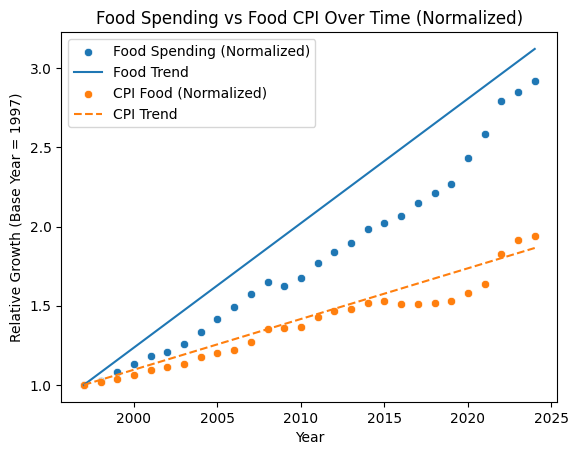

Food Spending Growth Rate: 24428.835361247948
CPI Growth Rate: 4.899116881043606


In [ ]:

# Clean column names
df.columns = [str(col).strip().lower().replace(" ", "_") for col in df.columns]

print(df.columns)

# Select relevant columns
data = df[[
    "year",
    "total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)"
]].dropna()

data.columns = ["year", "food_spending"]

# Convert types
data["year"] = pd.to_numeric(data["year"], errors="coerce")
data["food_spending"] = pd.to_numeric(data["food_spending"], errors="coerce")
data = data.dropna()

# ---- Add Wage Data (Example Placeholder) ----
# Replace this with real BLS/FRED data later
#data["avg_wage"] = 30000 + (data["year"] - data["year"].min()) * 800

# ---- LOAD CPI DATA ----
cpi = pd.read_csv("CPI_food_at_home.csv")

# Convert date column
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])

# Extract year
cpi["year"] = cpi["observation_date"].dt.year

# Rename CPI column for clarity
cpi = cpi.rename(columns={"CUSR0000SAF11": "cpi_food"})

# ---- AGGREGATE TO YEARLY AVERAGE ----
cpi_yearly = cpi.groupby("year")["cpi_food"].mean().reset_index()

# ---- FILTER YEARS TO MATCH MAIN DATA ----
cpi_yearly = cpi_yearly[
    (cpi_yearly["year"] >= data["year"].min()) &
    (cpi_yearly["year"] <= data["year"].max())
]

# ---- MERGE WITH MAIN DATA ----
data = pd.merge(data, cpi_yearly, on="year", how="inner")

# ---- REGRESSION MODELS ----
X = data["year"].values.reshape(-1, 1)

food_model = LinearRegression().fit(X, data["food_spending"])
cpi_model = LinearRegression().fit(X, data["cpi_food"])

food_trend = food_model.predict(X)
cpi_trend = cpi_model.predict(X)

# ---- NORMALIZE DATA FOR READABLE COMPARISON ----
# (IMPORTANT: CPI and spending are on completely different scales)
data["food_norm"] = data["food_spending"] / data["food_spending"].iloc[0]
data["cpi_norm"] = data["cpi_food"] / data["cpi_food"].iloc[0]

food_trend_norm = food_trend / food_trend[0]
cpi_trend_norm = cpi_trend / cpi_trend[0]

# ---- PLOT ----
plt.figure()

sns.scatterplot(x=data["year"], y=data["food_norm"], label="Food Spending (Normalized)")
plt.plot(data["year"], food_trend_norm, label="Food Trend")

sns.scatterplot(x=data["year"], y=data["cpi_norm"], label="CPI Food (Normalized)")
plt.plot(data["year"], cpi_trend_norm, linestyle="--", label="CPI Trend")

plt.title("Food Spending vs Food CPI Over Time (Normalized)")
plt.xlabel("Year")
plt.ylabel("Relative Growth (Base Year = 1997)")
plt.legend()

plt.show()

# ---- OUTPUT TRENDS ----
print("Food Spending Growth Rate:", food_model.coef_[0])
print("CPI Growth Rate:", cpi_model.coef_[0])

#Annual Groceries Cost Graph Compared to Wages Growth over years 1997-2024


In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving median_hourly_private_employees.csv to median_hourly_private_employees.csv


In [ ]:
df = pd.read_excel("nominal_expenditures_no_taxes_tips.xlsx", header=0)

In [ ]:
#df.columns = [str(col).strip().lower().replace(" ", "_") for col in df.columns]

df.columns = [
    str(col).strip().lower().replace(" ", "_").replace("-", "_")
    for col in df.columns
]

# Drop completely empty columns
df = df.loc[:, ~df.columns.str.contains("^unnamed")]

print(df.columns)

Index(['year',
       'food_sales_at_grocery_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_convenience_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_food_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_warehouse_clubs_and_supercenters_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_stores_and_foodservice_(millions_of_nominal_u.s._dollars)',
       'direct_food_selling_by_farmers,_manufacturers,_and_wholesalers_(millions_of_nominal_u.s._dollars)',
       'home_food_production_and_donations_(millions_of_nominal_u.s._dollars)',
       'total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_full_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_limited_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_drinking_places_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_hotels_and_motels_(millions_of_nominal_u.s.

Index(['year',
       'food_sales_at_grocery_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_convenience_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_food_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_warehouse_clubs_and_supercenters_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_stores_and_foodservice_(millions_of_nominal_u.s._dollars)',
       'direct_food_selling_by_farmers,_manufacturers,_and_wholesalers_(millions_of_nominal_u.s._dollars)',
       'home_food_production_and_donations_(millions_of_nominal_u.s._dollars)',
       'total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_full_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_limited_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_drinking_places_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_hotels_and_motels_(millions_of_nominal_u.s.

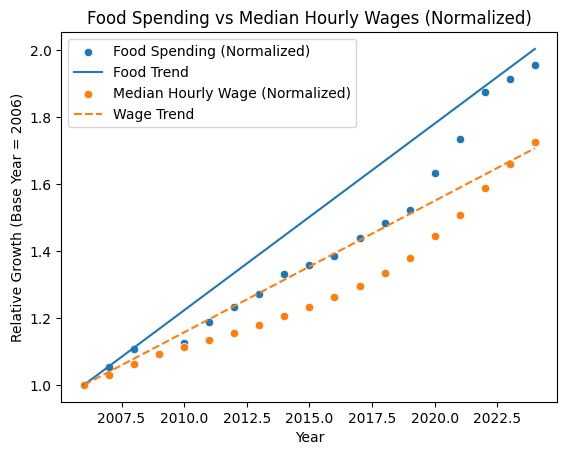

Food Spending Growth Rate: 27651.1819122807
Wage Growth Rate: 0.7563935672514617


In [ ]:

# Clean column names
df.columns = [str(col).strip().lower().replace(" ", "_") for col in df.columns]

print(df.columns)

# Select relevant columns
data = df[[
    "year",
    "total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)"
]].dropna()

data.columns = ["year", "food_spending"]

# Convert types
data["year"] = pd.to_numeric(data["year"], errors="coerce")
data["food_spending"] = pd.to_numeric(data["food_spending"], errors="coerce")
data = data.dropna()

# ---- Add Wage Data (Example Placeholder) ----
# Replace this with real BLS/FRED data later
# ---- LOAD WAGE DATA ----
wages = pd.read_csv("median_hourly_private_employees.csv")

# Convert date column
wages["observation_date"] = pd.to_datetime(wages["observation_date"])

# Extract year
wages["year"] = wages["observation_date"].dt.year

# Rename wage column
wages = wages.rename(columns={"CES0500000003": "avg_wage"})

# ---- AGGREGATE TO YEARLY AVERAGE ----
wages_yearly = wages.groupby("year")["avg_wage"].mean().reset_index()

# ---- MERGE WITH MAIN DATA ----
data = pd.merge(data, wages_yearly, on="year", how="inner")

# ---- Regression Models ----
# ---- REGRESSION MODELS ----
X = data["year"].values.reshape(-1, 1)

food_model = LinearRegression().fit(X, data["food_spending"])
wage_model = LinearRegression().fit(X, data["avg_wage"])

food_trend = food_model.predict(X)
wage_trend = wage_model.predict(X)

# ---- NORMALIZE FOR COMPARISON ----
data["food_norm"] = data["food_spending"] / data["food_spending"].iloc[0]
data["wage_norm"] = data["avg_wage"] / data["avg_wage"].iloc[0]

food_trend_norm = food_trend / food_trend[0]
wage_trend_norm = wage_trend / wage_trend[0]

# ---- PLOT ----
plt.figure()

sns.scatterplot(x=data["year"], y=data["food_norm"], label="Food Spending (Normalized)")
plt.plot(data["year"], food_trend_norm, label="Food Trend")

sns.scatterplot(x=data["year"], y=data["wage_norm"], label="Median Hourly Wage (Normalized)")
plt.plot(data["year"], wage_trend_norm, linestyle="--", label="Wage Trend")

plt.title("Food Spending vs Median Hourly Wages (Normalized)")
plt.xlabel("Year")
plt.ylabel("Relative Growth (Base Year = 2006)")
plt.legend()

plt.show()

# ---- OUTPUT ----
print("Food Spending Growth Rate:", food_model.coef_[0])
print("Wage Growth Rate:", wage_model.coef_[0])

## How do children in a household affect the cost of living grocery-wise over the years?

Saving cnpp-moderatecostplan-sept2007-present.xlsx to cnpp-moderatecostplan-sept2007-present (2).xlsx
Saving usda-moderatecostplan-pre-march2003.xlsx to usda-moderatecostplan-pre-march2003 (2).xlsx
Saving usda-moderatecostplan-march2003-aug2007.xlsx to usda-moderatecostplan-march2003-aug2007 (2).xlsx
  geographic_area fam_indv                group  \
0   Mainland U.S.   Family               Couple   
1   Mainland U.S.   Family  Couple and children   
2   Mainland U.S.   Family  Couple and children   
3   Mainland U.S.   Family               Couple   
4   Mainland U.S.   Family               Couple   

                                           age  year    month      food_plan  \
0                                  20-50 years  1994  January  Moderate-cost   
1  20-50 years and children 6-8 and 9-11 years  1994  January  Moderate-cost   
2  20-50 years and children 6-8 and 9-11 years  1994    March  Moderate-cost   
3                                  20-50 years  1994    March  Moderate

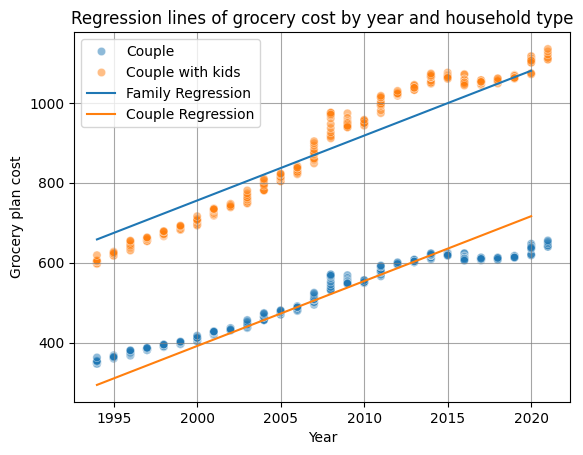

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import numpy as np

from google.colab import files
uploaded = files.upload()

# First we read the 3 food plan sets using pandas
pre_2003_foodplan = pd.read_excel(
    "usda-moderatecostplan-pre-march2003.xlsx", sheet_name="Moderate-Cost 94-03"
)
foodplan_03_07 = pd.read_excel(
    "usda-moderatecostplan-march2003-aug2007.xlsx",
    sheet_name="Moderate-Cost 03-07",
)
foodplan_07_present = pd.read_excel(
    "cnpp-moderatecostplan-sept2007-present.xlsx",
    sheet_name="Moderate-Cost 07-Pres",
)

norm1 = pre_2003_foodplan[
    (pre_2003_foodplan["geographic_area"] == "Mainland U.S.")
    & (pre_2003_foodplan["frequency"] == "Monthly")
].copy()
norm2 = foodplan_03_07[
    (foodplan_03_07["geographic_area"] == "Mainland U.S.")
    & (foodplan_03_07["frequency"] == "Monthly")
].copy()
norm3 = foodplan_07_present[
    (foodplan_07_present["location"] == "Mainland U.S.")
    & (foodplan_07_present["frequency"] == "Monthly")
].copy()

# We then normalized some column names and converted the year and cost columns to numbers for analysis
norm3 = norm3.rename(columns={"location": "geographic_area"})
norm1["year"] = pd.to_numeric(norm1["year"], errors="coerce")
norm2["year"] = pd.to_numeric(norm2["year"], errors="coerce")
norm3["year"] = pd.to_numeric(norm3["year"], errors="coerce")

norm1["cost"] = pd.to_numeric(norm1["cost"], errors="coerce")
norm2["cost"] = pd.to_numeric(norm2["cost"], errors="coerce")
norm3["cost"] = pd.to_numeric(norm3["cost"], errors="coerce")


couple1 = norm1[(norm1['fam_indv'] == 'Family') & (norm1['group'] == 'Couple') & (norm1['age'] == '20-50 years')].copy()
couple2 = norm2[(norm2['fam_indv'] == 'Family') & (norm2['group'] == 'Couple') & (norm2['age'] == '20-50 years')].copy()
couple3 = norm3[(norm3['fam_indv'] == 'Family') & (norm3['group'] == 'Couple') & (norm3['age'] == '19-50 years')].copy()

with_kids1 = norm1[(norm1['fam_indv'] == 'Family') & (norm1['group'] == 'Couple and children') & (norm1['age'] == '20-50 years and children 6-8 and 9-11 years')].copy()
with_kids2 = norm2[(norm2['fam_indv'] == 'Family') & (norm2['group'] == 'Couple and children') & (norm2['age'] == '20-50 years and children 6-8 and 9-11 years')].copy()
with_kids3 = norm3[(norm3['fam_indv'] == 'Family') & (norm3['group'] == 'Couple and children') & (norm3['age'] == '19-50 years and children 6-8 and 9-11 years')].copy()

couple1['household_type'] = 'Couple'
couple2['household_type'] = 'Couple'
couple3['household_type'] = 'Couple'

with_kids1['household_type'] = 'Couple with kids'
with_kids2['household_type'] = 'Couple with kids'
with_kids3['household_type'] = 'Couple with kids'

kept = [
        "geographic_area",
        "fam_indv",
        "group",
        "age",
        "year",
        "month",
        "food_plan",
        "frequency",
        "cost",
        "household_type"
    ]
couple1 = couple1[kept]
couple2 = couple2[kept]
couple3 = couple3[kept]

with_kids1 = with_kids1[kept]
with_kids2 = with_kids2[kept]
with_kids3 = with_kids3[kept]

household_group = pd.concat([couple1, couple2, couple3, with_kids1, with_kids2, with_kids3], ignore_index=True)

household_group["date"] = pd.to_datetime(
    household_group["month"] + " " + household_group["year"].astype(str), format="%B %Y"
)
household_group = household_group.sort_values("date").reset_index(drop=True)

print(household_group.head())

yearly_household_group = (
    household_group
    .groupby(["year", "household_type"], as_index=False)["cost"]
    .mean()
    .rename(columns={"cost": "avg_monthly_cost"})
)

household_group["has_children"] = (
    household_group["household_type"] == "Couple with kids"
).astype(int)

household_model = household_group[['year', 'household_type', 'cost']].dropna().copy()

household_model["has_children"] = (
    household_model["household_type"] == "Couple with kids"
).astype(int)

X = household_model[['year', 'has_children']]
Y = household_model['cost']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= .2, random_state=84)
model = LinearRegression()
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred))}")
print(f"R Squared: {r2_score(Y_test, y_pred)}")
print(f"Children Coefficent: {model.coef_[1]}")
print(f"Year Coefficent: {model.coef_[0]}")



sns.scatterplot(data=household_model, x='year', y='cost', hue='household_type', alpha =0.5)

years = np.arange(household_group['year'].min(), household_group['year'].max())

kids = pd.DataFrame({'year': years, 'has_children': 1})
no_kids = pd.DataFrame({'year': years, 'has_children': 0})

plt.plot(years, model.predict(kids), label="Family Regression")
plt.plot(years, model.predict(no_kids), label="Couple Regression")
plt.title("Regression lines of grocery cost by year and household type")
plt.xlabel("Year")
plt.ylabel("Grocery plan cost")
plt.grid(True, color='gray', alpha =.7)
plt.legend()
plt.show()




